## Claude

Saved!


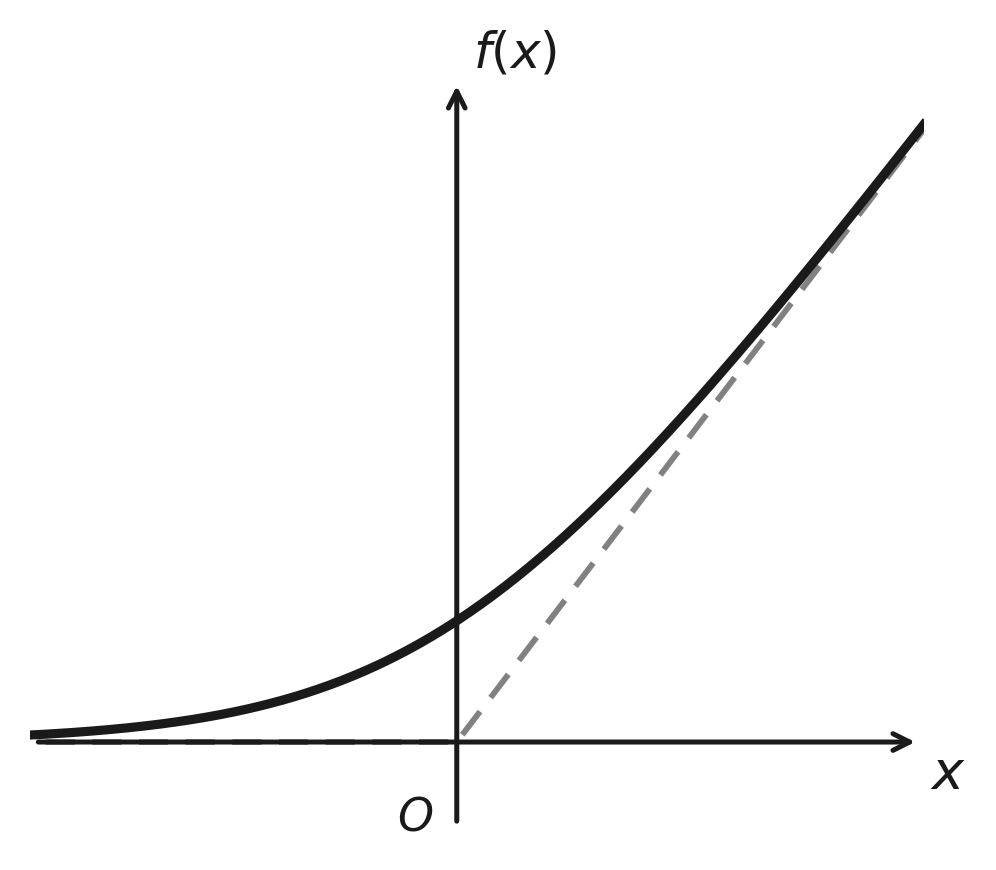

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

fig, ax = plt.subplots(figsize=(3.2, 2.8), dpi=300)

# ── 数据 ──
x = np.linspace(-3.5, 3.5, 400)
softplus = np.log1p(np.exp(x))          # softplus: ln(1 + e^x)
relu     = np.maximum(0, x)             # ReLU

# ── 曲线 ──
ax.plot(x, softplus, color='#1a1a1a', linewidth=2.2, zorder=3)
ax.plot(x, relu,     color='#1a1a1a', linewidth=1.4,
        linestyle='--', dashes=(5, 3), zorder=2, alpha=0.55)

# ── 坐标轴范围 ──
XMIN, XMAX = -3.2, 3.5
YMIN, YMAX = -0.5, 3.8
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)

# ── 隐藏默认 spines ──
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# ── 手绘风格的带箭头坐标轴 ──
arrow_kw = dict(
    arrowstyle='->', color='#1a1a1a', linewidth=1.2,
    mutation_scale=10, clip_on=False,
    transform=ax.transData,
)
# x 轴
ax.annotate('', xy=(XMAX, 0), xytext=(XMIN, 0),
            arrowprops=dict(arrowstyle='->', color='#1a1a1a',
                            lw=1.2, mutation_scale=10))
# y 轴
ax.annotate('', xy=(0, YMAX), xytext=(0, YMIN),
            arrowprops=dict(arrowstyle='->', color='#1a1a1a',
                            lw=1.2, mutation_scale=10))

# 原点标记
ax.text(-0.18, -0.32, '$O$', fontsize=11, ha='right', va='top', color='#1a1a1a')

# 轴标签
ax.text(XMAX + 0.05, -0.05, '$x$', fontsize=13, ha='left', va='top',
        fontstyle='italic', color='#1a1a1a')
ax.text(0.12, YMAX, '$f(x)$', fontsize=12, ha='left', va='bottom', color='#1a1a1a')

# ── 不显示图例（用户要求删除左上方两个函数的图例） ──

# ── 背景 ──
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout(pad=0.3)

plt.savefig('softplus.pdf',
            bbox_inches='tight', facecolor='white')
plt.savefig('softplus.svg',
            bbox_inches='tight', facecolor='white', format='svg')
plt.savefig('softplus.png',
            bbox_inches='tight', facecolor='white', dpi=300)
print("Saved!")


'\nplt.savefig(\'/mnt/user-data/outputs/post_spike_filter_v2.svg\',\n            bbox_inches=\'tight\', facecolor=\'white\', format=\'svg\')\nplt.savefig(\'/mnt/user-data/outputs/post_spike_filter_v2.pdf\',\n            bbox_inches=\'tight\', facecolor=\'white\')\nplt.savefig(\'/mnt/user-data/outputs/post_spike_filter_v2.png\',\n            bbox_inches=\'tight\', facecolor=\'white\', dpi=300)\nprint("Saved!")\n'

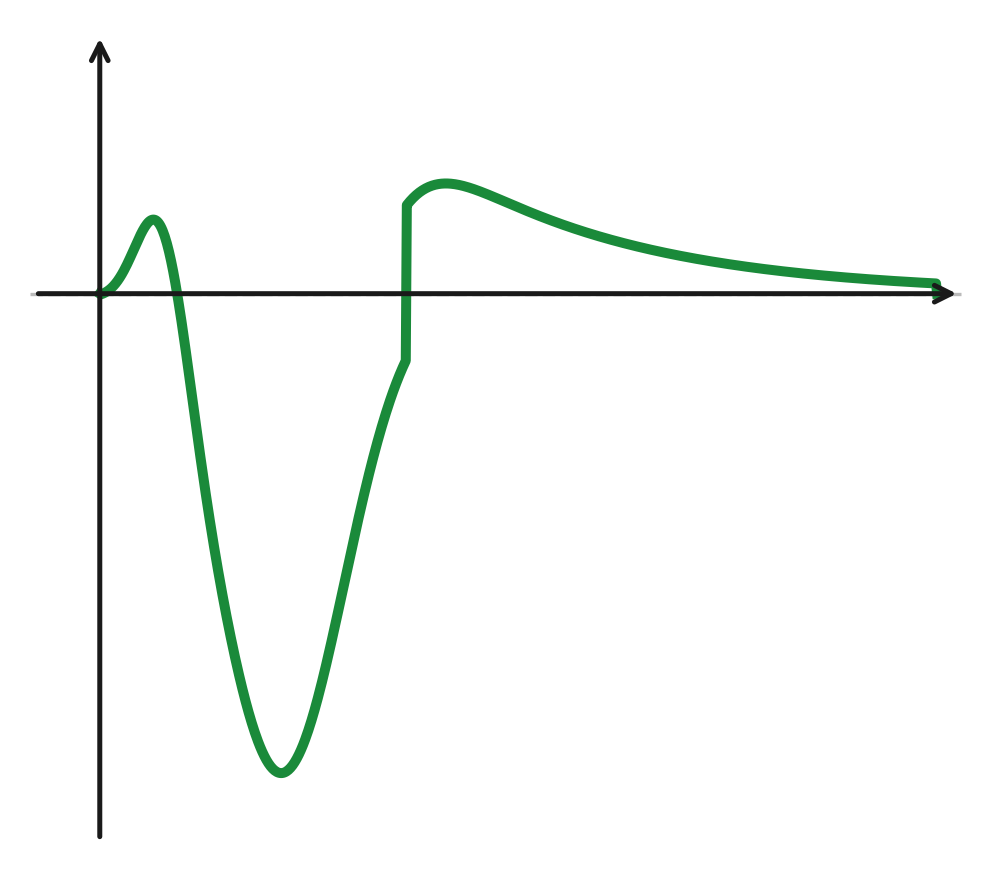

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

fig, ax = plt.subplots(figsize=(3.2, 2.8), dpi=300)

# ── 构造曲线：正向小峰 → 大负谷 → 缓慢正向反弹衰减至零
# 用三个高斯/指数分量叠加
t = np.linspace(0, 6.0, 800)

# 分量1：早期正向小峰
c1 =  0.30 * np.exp(-((t - 0.45)**2) / (2 * 0.18**2))
# 分量2：主负向深谷
c2 = -1.00 * np.exp(-((t - 1.30)**2) / (2 * 0.45**2))
# 分量3：缓慢正向反弹，指数衰减
c3 =  0.32 * np.exp(-(t - 2.2) / 1.4) * (t > 2.2)

h = c1 + c2 + c3

# 起点和终点钳制为 0
h[0] = 0.0
h[-1] = 0.0

# ── 坐标范围 ──
XMIN, XMAX = -0.5, 6.2
YMIN, YMAX = -1.15, 0.55

ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)

# ── 零线 ──
ax.axhline(0, color='#BBBBBB', linewidth=0.8, linestyle='--', zorder=1)

# ── 主曲线（绿色，与参考图一致）──
ax.plot(t, h, color='#1a8a3a', linewidth=2.4, zorder=3)

# ── 隐藏默认 spines ──
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# ── 带箭头坐标轴（无标签，无原点标注）──
ax.annotate('', xy=(XMAX, 0), xytext=(XMIN, 0),
            arrowprops=dict(arrowstyle='->', color='#1a1a1a',
                            lw=1.2, mutation_scale=10))
ax.annotate('', xy=(0, YMAX), xytext=(0, YMIN),
            arrowprops=dict(arrowstyle='->', color='#1a1a1a',
                            lw=1.2, mutation_scale=10))

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout(pad=0.3)

'''
plt.savefig('/mnt/user-data/outputs/post_spike_filter_v2.svg',
            bbox_inches='tight', facecolor='white', format='svg')
plt.savefig('/mnt/user-data/outputs/post_spike_filter_v2.pdf',
            bbox_inches='tight', facecolor='white')
plt.savefig('/mnt/user-data/outputs/post_spike_filter_v2.png',
            bbox_inches='tight', facecolor='white', dpi=300)
print("Saved!")
'''
